In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
df = sns.load_dataset('titanic')

# select useful columns 
df = df[['survived','pclass','sex','age','sibsp','parch','fare']].copy()

# handle missing values 
df['age'].fillna(df['age'].median(),inplace=True)

# encode categorical columns 
df['sex'] = df['sex'].map({'male':1, 'female':0})

X = df.drop(columns=['survived'])
y = df['survived']

print(df.shape)
print(y.value_counts())
display(df.head())

(891, 7)
survived
0    549
1    342
Name: count, dtype: int64


C:\Users\husna\AppData\Local\Temp\ipykernel_11192\2735682664.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(),inplace=True)


,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


In [10]:
# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fix the NaN (Missing Value) Issue for BOTH sets
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# 3. Baseline: Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)   
y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# 4. Advanced: Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.500000, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)
gbc_accuracy = accuracy_score(y_test, y_pred_gbc)

# 5. Compare Results
print(f"Single Decision Tree Accuracy : {dt_accuracy:.4f} ({(dt_accuracy*100):.1f}%)")
print(f"Gradient Boosting Accuracy    : {gbc_accuracy:.4f} ({(gbc_accuracy*100):.1f}%)")

Single Decision Tree Accuracy : 0.7989 (79.9%)
Gradient Boosting Accuracy    : 0.8156 (81.6%)


In [9]:
learning_rates = [0.01,0.1,0.5,1]

for lr in learning_rates:
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3,random_state=42)
    model.fit(X_train,y_train)

    acc = accuracy_score(y_test, model.predict(X_test))

    print(f"learning rate: {lr:<f} --> {(acc*100):.4f}%")

learning rate: 0.010000 --> 76.5363%
learning rate: 0.100000 --> 80.4469%
learning rate: 0.500000 --> 81.5642%
learning rate: 1.000000 --> 79.3296%


C:\Users\husna\AppData\Local\Temp\ipykernel_11192\527518085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=X_train.columns, palette='viridis')


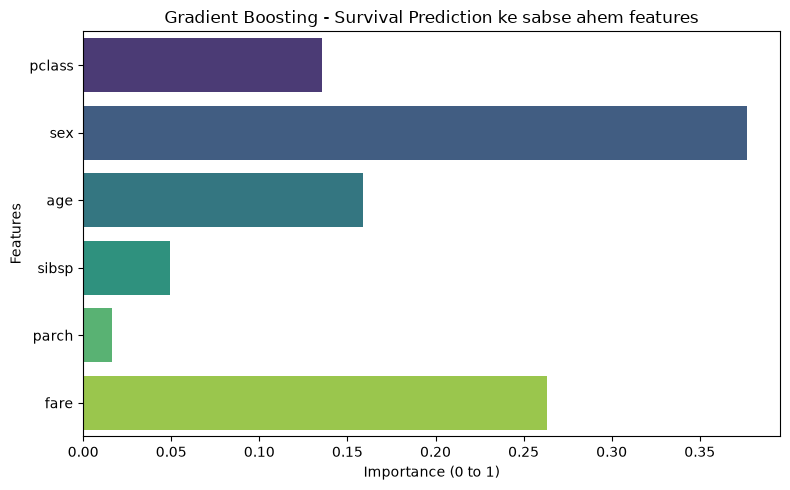

In [11]:

best_gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=3, random_state=42)
best_gbc.fit(X_train, y_train)

importance = best_gbc.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importance, y=X_train.columns, palette='viridis')
plt.title('Gradient Boosting - Survival Prediction ke sabse ahem features')
plt.xlabel('Importance (0 to 1)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()